In [1]:
import pandas as pd

df = pd.read_csv("metrics_summary.csv")
df

,dataset_type,dataset_name,sample_index,rmse_norm,mae_norm,mape_norm,rmse_unnorm,mae_unnorm,mape_unnorm,y_true_total,...,pred_unn_posinf,pred_unn_neginf,pred_unn_invalid,pred_unn_invalid_pct,valid_used_norm,invalid_used_norm,used_invalid_pct_norm,valid_used_unnorm,invalid_used_unnorm,used_invalid_pct_unnorm
0,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,0,0.004343,0.003463,0.788828,0.001455,0.000963,0.231792,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0
1,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,1,0.004782,0.003867,1.200795,0.001212,0.000902,0.278479,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0
2,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,2,0.004631,0.003670,0.726488,0.001855,0.001054,0.230547,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0
3,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,3,0.004593,0.003796,1.061677,0.001033,0.000750,0.208127,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0
4,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,4,0.005533,0.004236,0.930689,0.001931,0.000980,0.231087,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0
5,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,5,0.005361,0.004456,1.160728,0.001151,0.000750,0.173064,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0
6,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,6,0.006384,0.005103,0.880180,0.001476,0.001015,0.187524,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0
7,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,7,0.004873,0.003919,0.840318,0.001214,0.000767,0.148375,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0
8,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,8,0.004750,0.003798,1.225147,0.001084,0.000762,0.259840,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0
9,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,9,0.005712,0.004400,1.226099,0.001174,0.000781,0.246523,1024,...,0,0,0,0.0,1024,0,0.0,1024,0,0.0


In [12]:
import os
import pandas as pd

# 假设 csv 文件名
csv_file = "metrics_summary.csv"
df = pd.read_csv(csv_file)

# 过滤出 sample_index 为 0~4 的
df_filtered = df[df['sample_index'].isin([0, 1, 2, 3, 4])]

results = []
grouped = df_filtered.groupby(['dataset_type', 'dataset_name'])

for (dtype, dname), group in grouped:
    norm_rmse_mean = group['rmse_norm'].mean()
    norm_mae_mean = group['mae_norm'].mean()
    results.append({
        'dataset_type': dtype,
        'dataset_name': dname,
        'normalization': 'norm',
        'rmse_mean': norm_rmse_mean,
        'mae_mean': norm_mae_mean
    })
    
    unnorm_rmse_mean = group['rmse_unnorm'].mean()
    unnorm_mae_mean = group['mae_unnorm'].mean()
    results.append({
        'dataset_type': dtype,
        'dataset_name': dname,
        'normalization': 'unnorm',
        'rmse_mean': unnorm_rmse_mean,
        'mae_mean': unnorm_mae_mean
    })

summary_df = pd.DataFrame(results)

# 根据 dataset_type 内容来判断
def extract_data_type(val: str) -> str:
    val = val.lower()
    if "train" in val:
        return "train"
    elif "test" in val:
        return "test"
    else:
        return "unknown"

summary_df["data_type"] = summary_df["dataset_type"].apply(extract_data_type)

summary_df



,dataset_type,dataset_name,normalization,rmse_mean,mae_mean,data_type
0,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,norm,0.006368,0.004334,test
1,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,unnorm,0.003123,0.001548,test
2,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,norm,0.004776,0.003806,train
3,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,gaussiandiffdistr_cl0.03_dim=1d_solver=exponax...,unnorm,0.001497,0.000930,train


In [11]:
filename

'metrics_summary.csv'

In [10]:
summary_df.columns

Index(['dataset_type', 'dataset_name', 'normalization', 'rmse_mean',
       'mae_mean', 'split'],
      dtype='object')

In [18]:
275/5*2

110.0

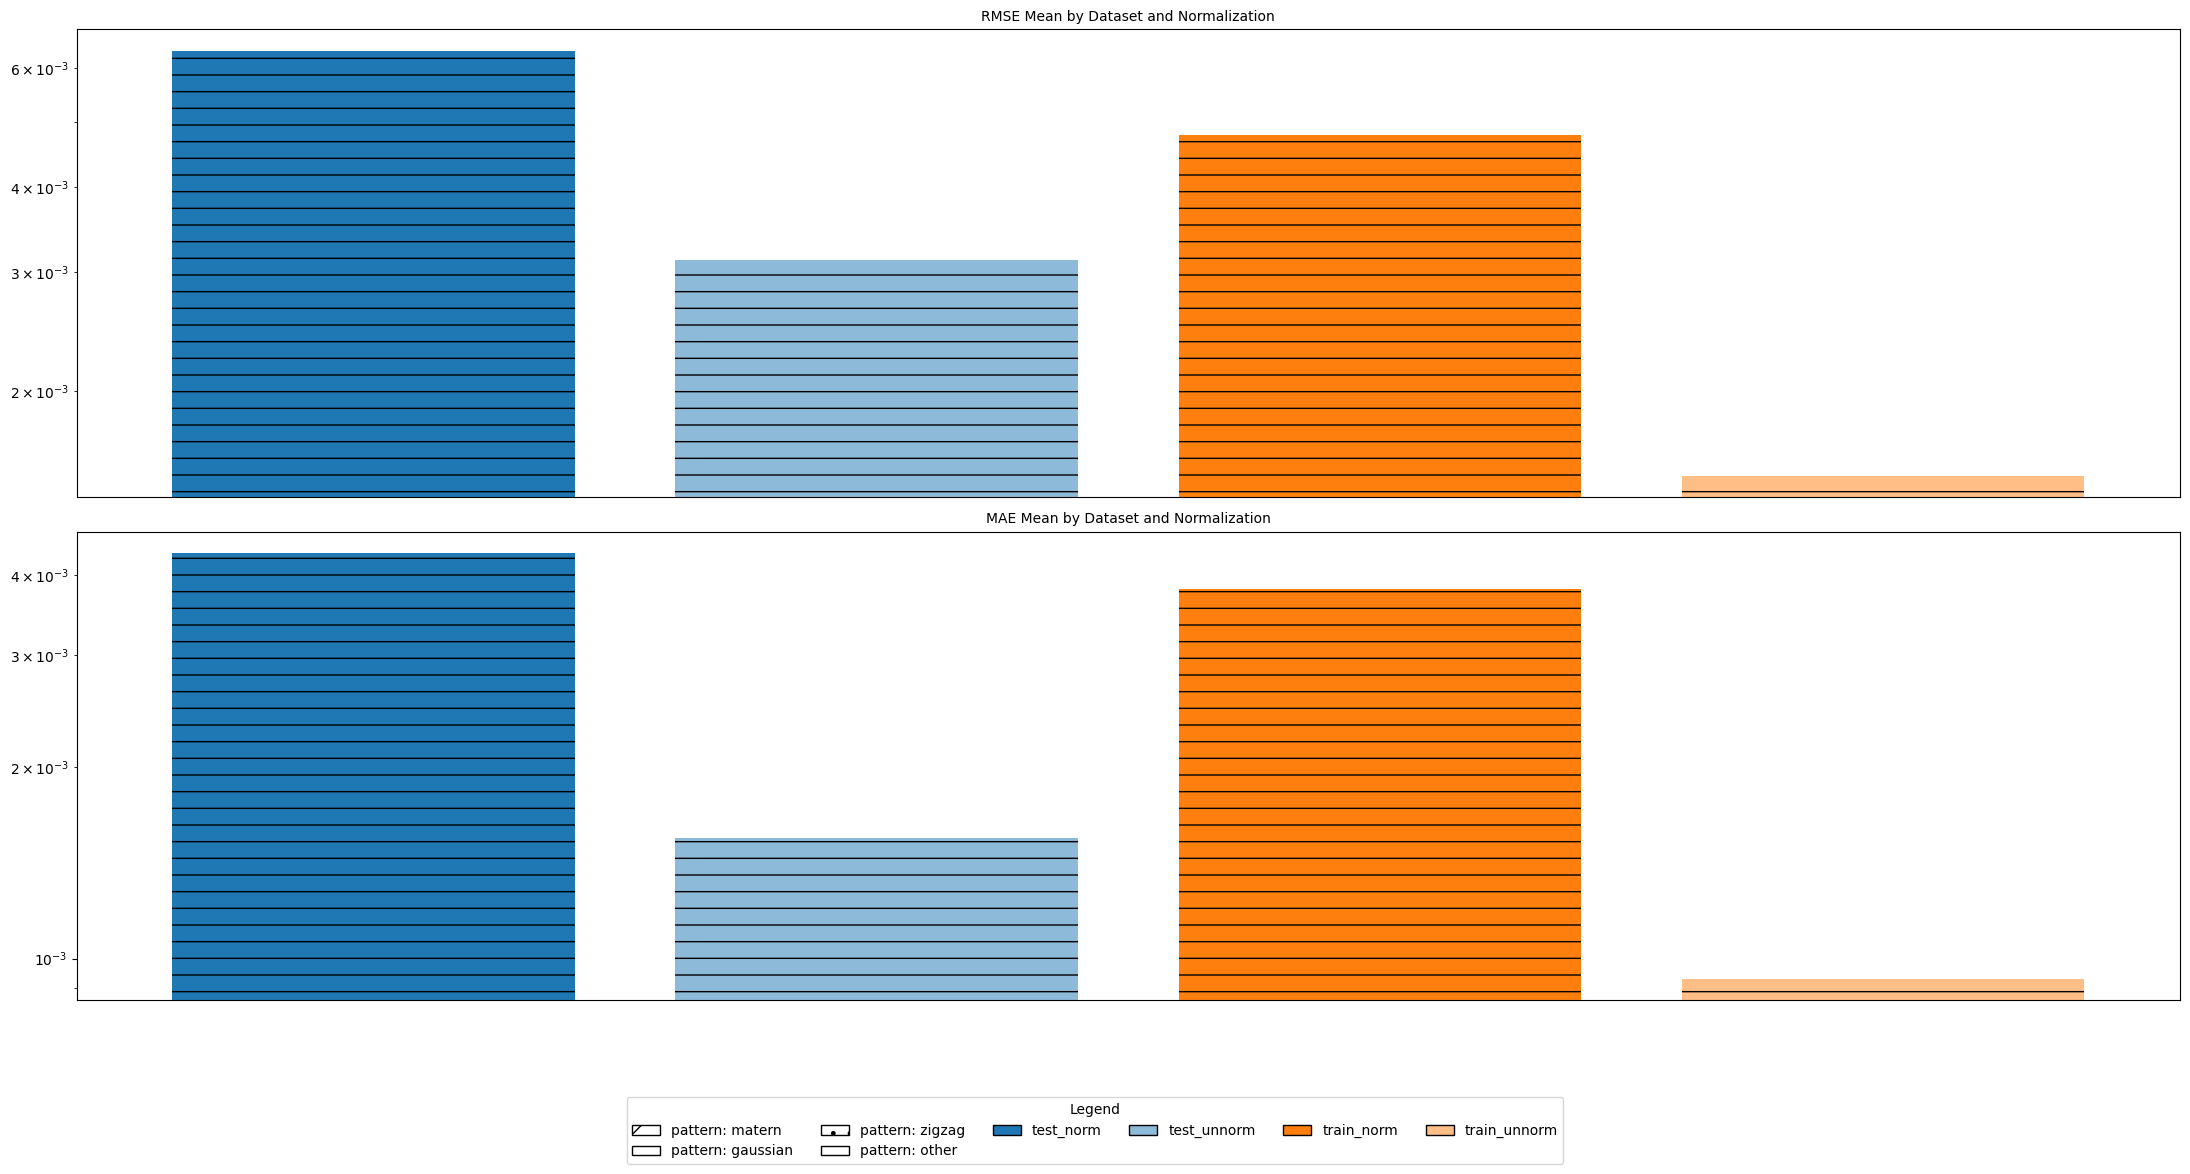

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re

# 假设 summary_df 已经存在

# 你的颜色和 alpha 映射逻辑不变
data_types = summary_df['data_type'].unique()
base_colors = dict(zip(data_types, plt.cm.tab10.colors[:len(data_types)]))

def get_color(row):
    base = base_colors[row['data_type']]
    alpha = 1.0 if row['normalization'] == 'norm' else 0.5
    return (*base[:4], alpha)

colors = summary_df.apply(get_color, axis=1)

# 提取 pattern
def extract_pattern(name):
    name = name.lower()
    if 'matern' in name:
        return 'matern'
    elif 'gaussian' in name:
        return 'gaussian'
    elif 'zigzag' in name:
        return 'zigzag'
    else:
        return 'other'

summary_df['pattern'] = summary_df['dataset_name'].apply(extract_pattern)

hatch_map = {
    'matern': '/',
    'gaussian': '-',
    'zigzag': '.',
    'other': None
}
hatches = summary_df['pattern'].map(hatch_map)

# 这里是完整label，确保唯一定位（避免重合）
summary_df['label'] = (
    summary_df['dataset_type'] + "_" +
    summary_df['normalization'] + "_" +
    summary_df['dataset_name']
)

# 生成简短label_2，画图时显示用
def make_label_2(row):
    name = row['dataset_name'].lower()
    pattern = row['pattern']
    if pattern == 'matern':
        cl = re.search(r'cl([0-9\.]+)', name)
        nu = re.search(r'nu([0-9\.]+)', name)
        cl_str = cl.group(1) if cl else '?'
        nu_str = nu.group(1) if nu else '?'
        return f"cl{cl_str}_nu{nu_str}"
    elif pattern == 'gaussian':
        cl = re.search(r'cl([0-9\.]+)', name)
        cl_str = cl.group(1) if cl else '?'
        return f"cl{cl_str}"
    elif pattern == 'zigzag':
        peaks = re.search(r'peaks([0-9]+)', name)
        peaks_str = peaks.group(1) if peaks else '?'
        return f"peaks{peaks_str}"
    else:
        return 'other'
fig = plt.figure(figsize=(22, 12))

# === RMSE ===
ax1 = plt.subplot(2, 1, 1)
bars = ax1.bar(summary_df['label'], summary_df['rmse_mean'], color=colors)
for bar, hatch in zip(bars, hatches):
    if hatch:
        bar.set_hatch(hatch)

ax1.set_yscale('log')
ax1.set_title('RMSE Mean by Dataset and Normalization', fontsize=10)

# 关键：隐藏 x 轴所有文字与刻度
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax1.set_xlabel(None)                 # 不显示 xlabel
# 如果想连轴线都隐藏（可选）
# ax1.spines['bottom'].set_visible(False)

# === MAE ===
ax2 = plt.subplot(2, 1, 2)
bars = ax2.bar(summary_df['label'], summary_df['mae_mean'], color=colors)
for bar, hatch in zip(bars, hatches):
    if hatch:
        bar.set_hatch(hatch)

ax2.set_yscale('log')
ax2.set_title('MAE Mean by Dataset and Normalization', fontsize=10)

# 同样隐藏 x 轴
ax2.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax2.set_xlabel(None)
# ax2.spines['bottom'].set_visible(False)  # 可选

# === Legend 仍然放底部 ===
# ... 你现有的 legend_elements 构造代码保持不变 ...

# === 构造 legend elements ===
legend_elements = []

# Pattern legend
for pat, hatch in hatch_map.items():
    if hatch:
        legend_elements.append(
            Patch(facecolor="white", edgecolor="black", hatch=hatch, label=f"pattern: {pat}")
        )
    else:
        legend_elements.append(
            Patch(facecolor="white", edgecolor="black", label=f"pattern: {pat}")
        )

# Color legend (dataset_type+normalization)
color_labels = summary_df[['data_type', 'normalization']].drop_duplicates()
for _, row in color_labels.iterrows():
    facecolor = (*base_colors[row['data_type']][:4], 1.0 if row['normalization']=="norm" else 0.5)
    label = f"{row['data_type']}_{row['normalization']}"
    legend_elements.append(Patch(facecolor=facecolor, edgecolor="black", label=label))

# === 放到底部 ===
plt.tight_layout(rect=[0, 0.15, 1, 1])
ncol = min(6, len(legend_elements))
fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, 0.02), ncol=ncol,
           title='Legend', frameon=True)


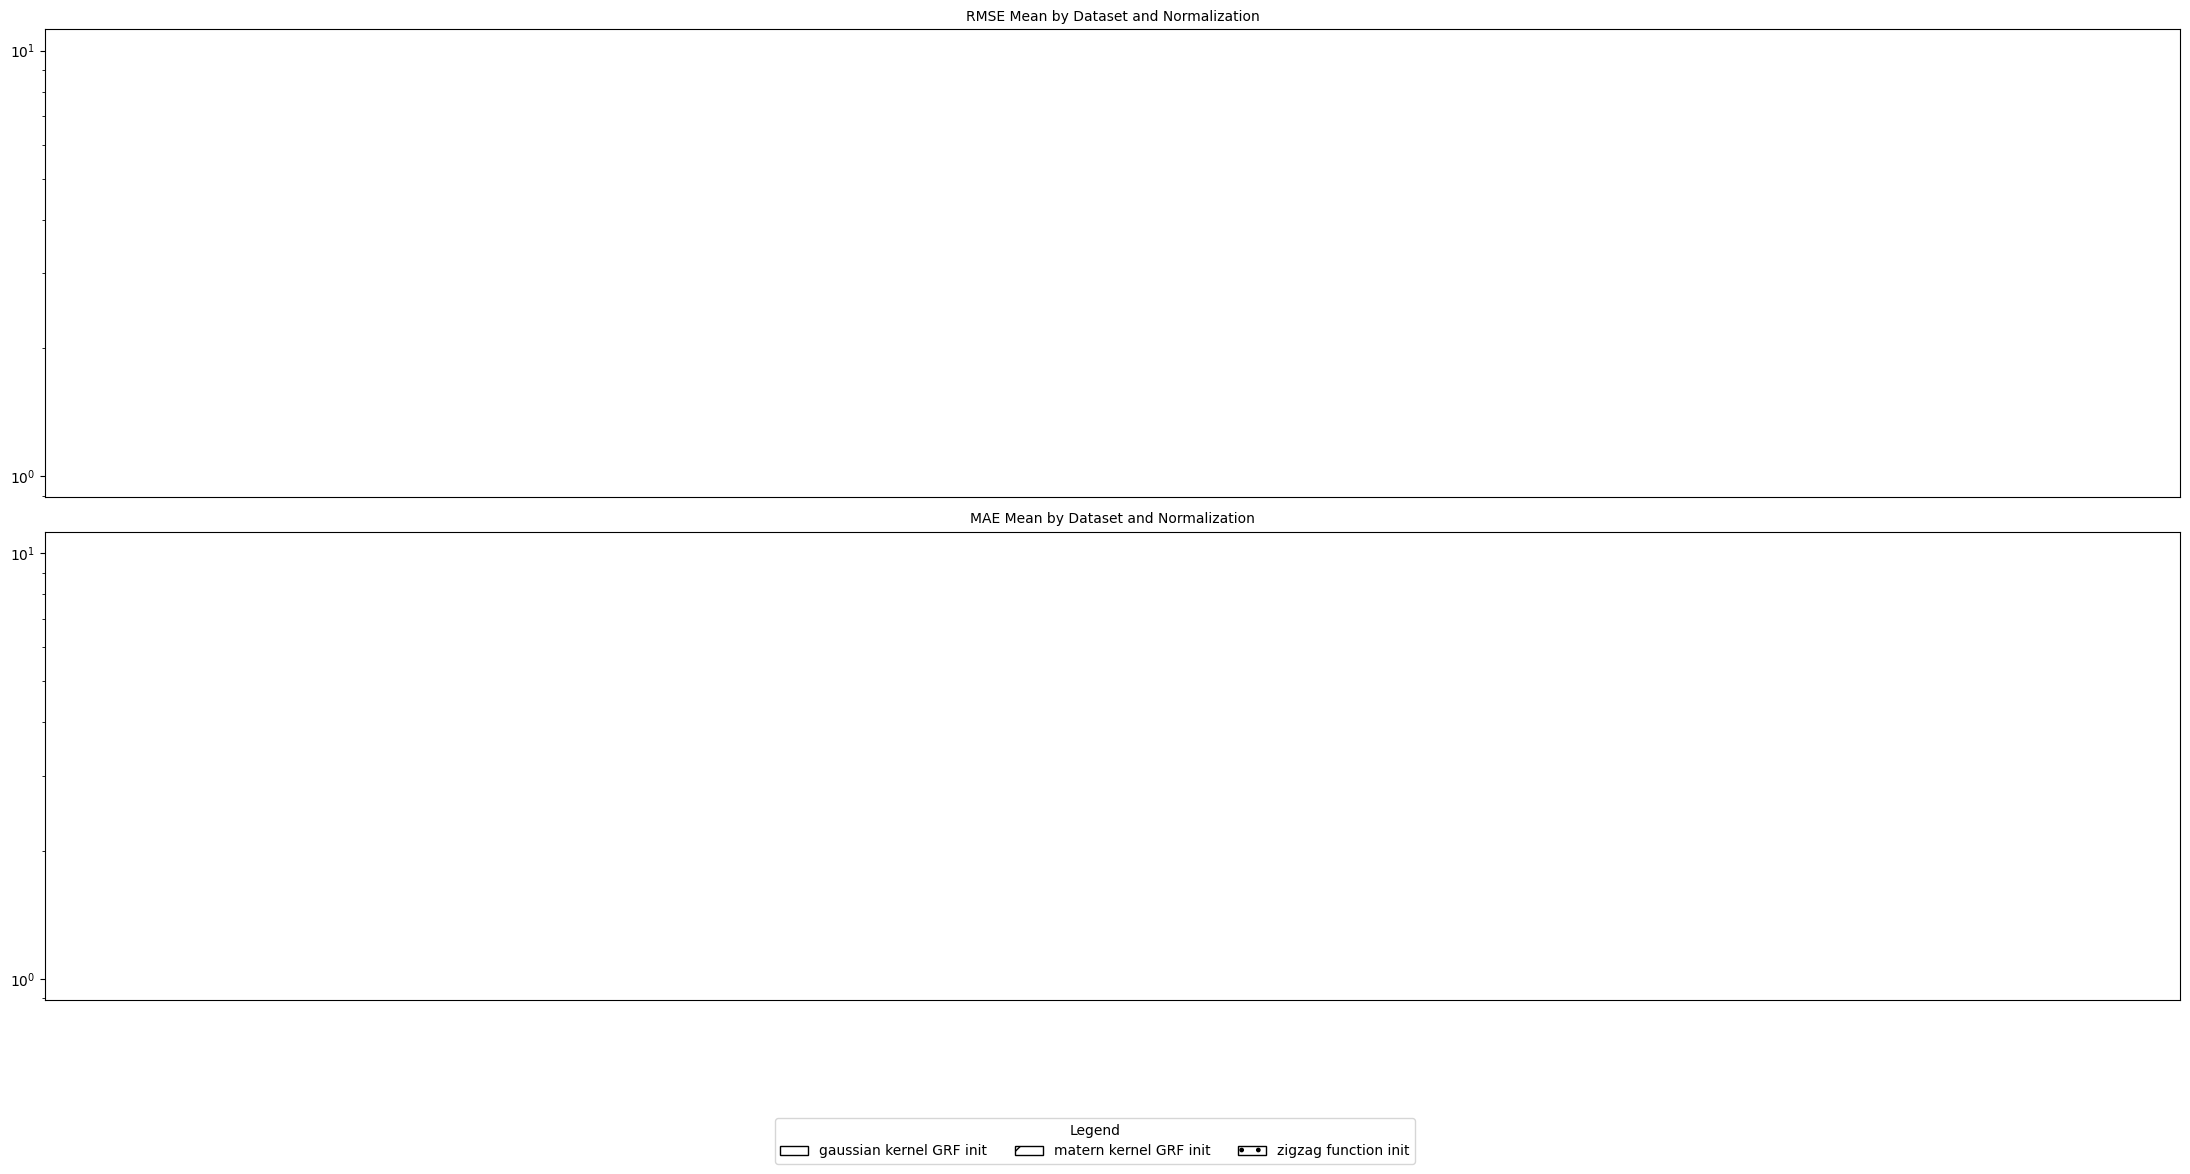

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re

# ===== 假设 summary_df 已经存在 =====
summary_df['label_2'] = summary_df.apply(make_label_2, axis=1)
# ——仅保留两种 range——
allowed_types = {'all_pos', 'range_0_0.5', 'range_0_2', 'range_0_3'}  # all_pos -> range=(0,1), range_0_0.5 -> range=(0,0.5)
summary_df = summary_df[summary_df['dataset_type'].isin(allowed_types)].copy()

# 提取 pattern（先于 hatches 计算）
def extract_pattern(name):
    name = name.lower()
    if 'matern' in name:
        return 'matern'
    elif 'gaussian' in name:
        return 'gaussian'
    elif 'zigzag' in name:
        return 'zigzag'
    else:
        return 'other'

summary_df['pattern'] = summary_df['dataset_name'].apply(extract_pattern)

hatch_map = {'matern': '/', 'gaussian': '-', 'zigzag': '.', 'other': None}
hatches = summary_df['pattern'].map(hatch_map)

# 唯一 label（不显示，但用于分组定位）
summary_df['label'] = (
    summary_df['dataset_type'] + "_" +
    summary_df['normalization'] + "_" +
    summary_df['dataset_name']
)

# ——颜色映射（基于过滤后的类型重建）——
dataset_types = summary_df['dataset_type'].unique()
base_colors = dict(zip(dataset_types, plt.cm.tab10.colors[:len(dataset_types)]))

def get_color(row):
    base = base_colors[row['dataset_type']]
    alpha = 1.0 if row['normalization'] == 'norm' else 0.5
    return (*base[:10], alpha)

colors = summary_df.apply(get_color, axis=1)
import numpy as np
x = np.arange(len(summary_df))
# ===== 画图（RMSE + MAE，x轴无文字，legend 底部） =====
fig = plt.figure(figsize=(22, 12))

# === RMSE ===
ax1 = plt.subplot(2, 1, 1)
bars = ax1.bar(summary_df['label'], summary_df['rmse_mean'], color=colors)
for bar, hatch in zip(bars, hatches):
    if hatch:
        bar.set_hatch(hatch)
ax1.set_yscale('log')
ax1.set_title('RMSE Mean by Dataset and Normalization', fontsize=10)
# ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax1.set_xlabel(None)
ax1.set_xticks(x)
ax1.set_xticklabels(summary_df['label_2'], rotation=90, fontsize=8)
ax1.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)  # 开启刻度和标签

# === MAE ===
ax2 = plt.subplot(2, 1, 2)
bars = ax2.bar(summary_df['label'], summary_df['mae_mean'], color=colors)
for bar, hatch in zip(bars, hatches):
    if hatch:
        bar.set_hatch(hatch)
ax2.set_yscale('log')
ax2.set_title('MAE Mean by Dataset and Normalization', fontsize=10)
# ax2.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax2.set_xlabel(None)
ax2.set_xticks(x)
ax2.set_xticklabels(summary_df['label_2'], rotation=90, fontsize=8)
ax2.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

# ——Legend（只包含两类 range）——
label_map = {
    'all_pos': 'range=(0,1)',
    'range_0_0.5': 'range=(0,0.5)',
    "range_0_2": "range=(0,2)",
    "range_0_3": "range=(0,3)",
}
legend_elements = []
for dtype in dataset_types:
    display_label = label_map.get(dtype, dtype)
    legend_elements.append(Patch(facecolor=base_colors[dtype],
                                 label=f'init {display_label}|model=normalized FNO1d', alpha=1.0))
    legend_elements.append(Patch(facecolor=base_colors[dtype],
                                 label=f'init {display_label}|model=unnormalized FNO1d', alpha=0.5))

# hatch 说明
for hatch, label in { 'gaussian': ('-', 'gaussian kernel GRF init'),
                      'matern': ('/', 'matern kernel GRF init'),
                      'zigzag': ('.', 'zigzag function init') }.values():
    legend_elements.append(Patch(facecolor='white', edgecolor='black', hatch=hatch, label=label))

plt.tight_layout(rect=[0, 0.15, 1, 1])
ncol = min(6, len(legend_elements))
fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, 0.02), ncol=ncol,
           title='Legend', frameon=True)

plt.show()


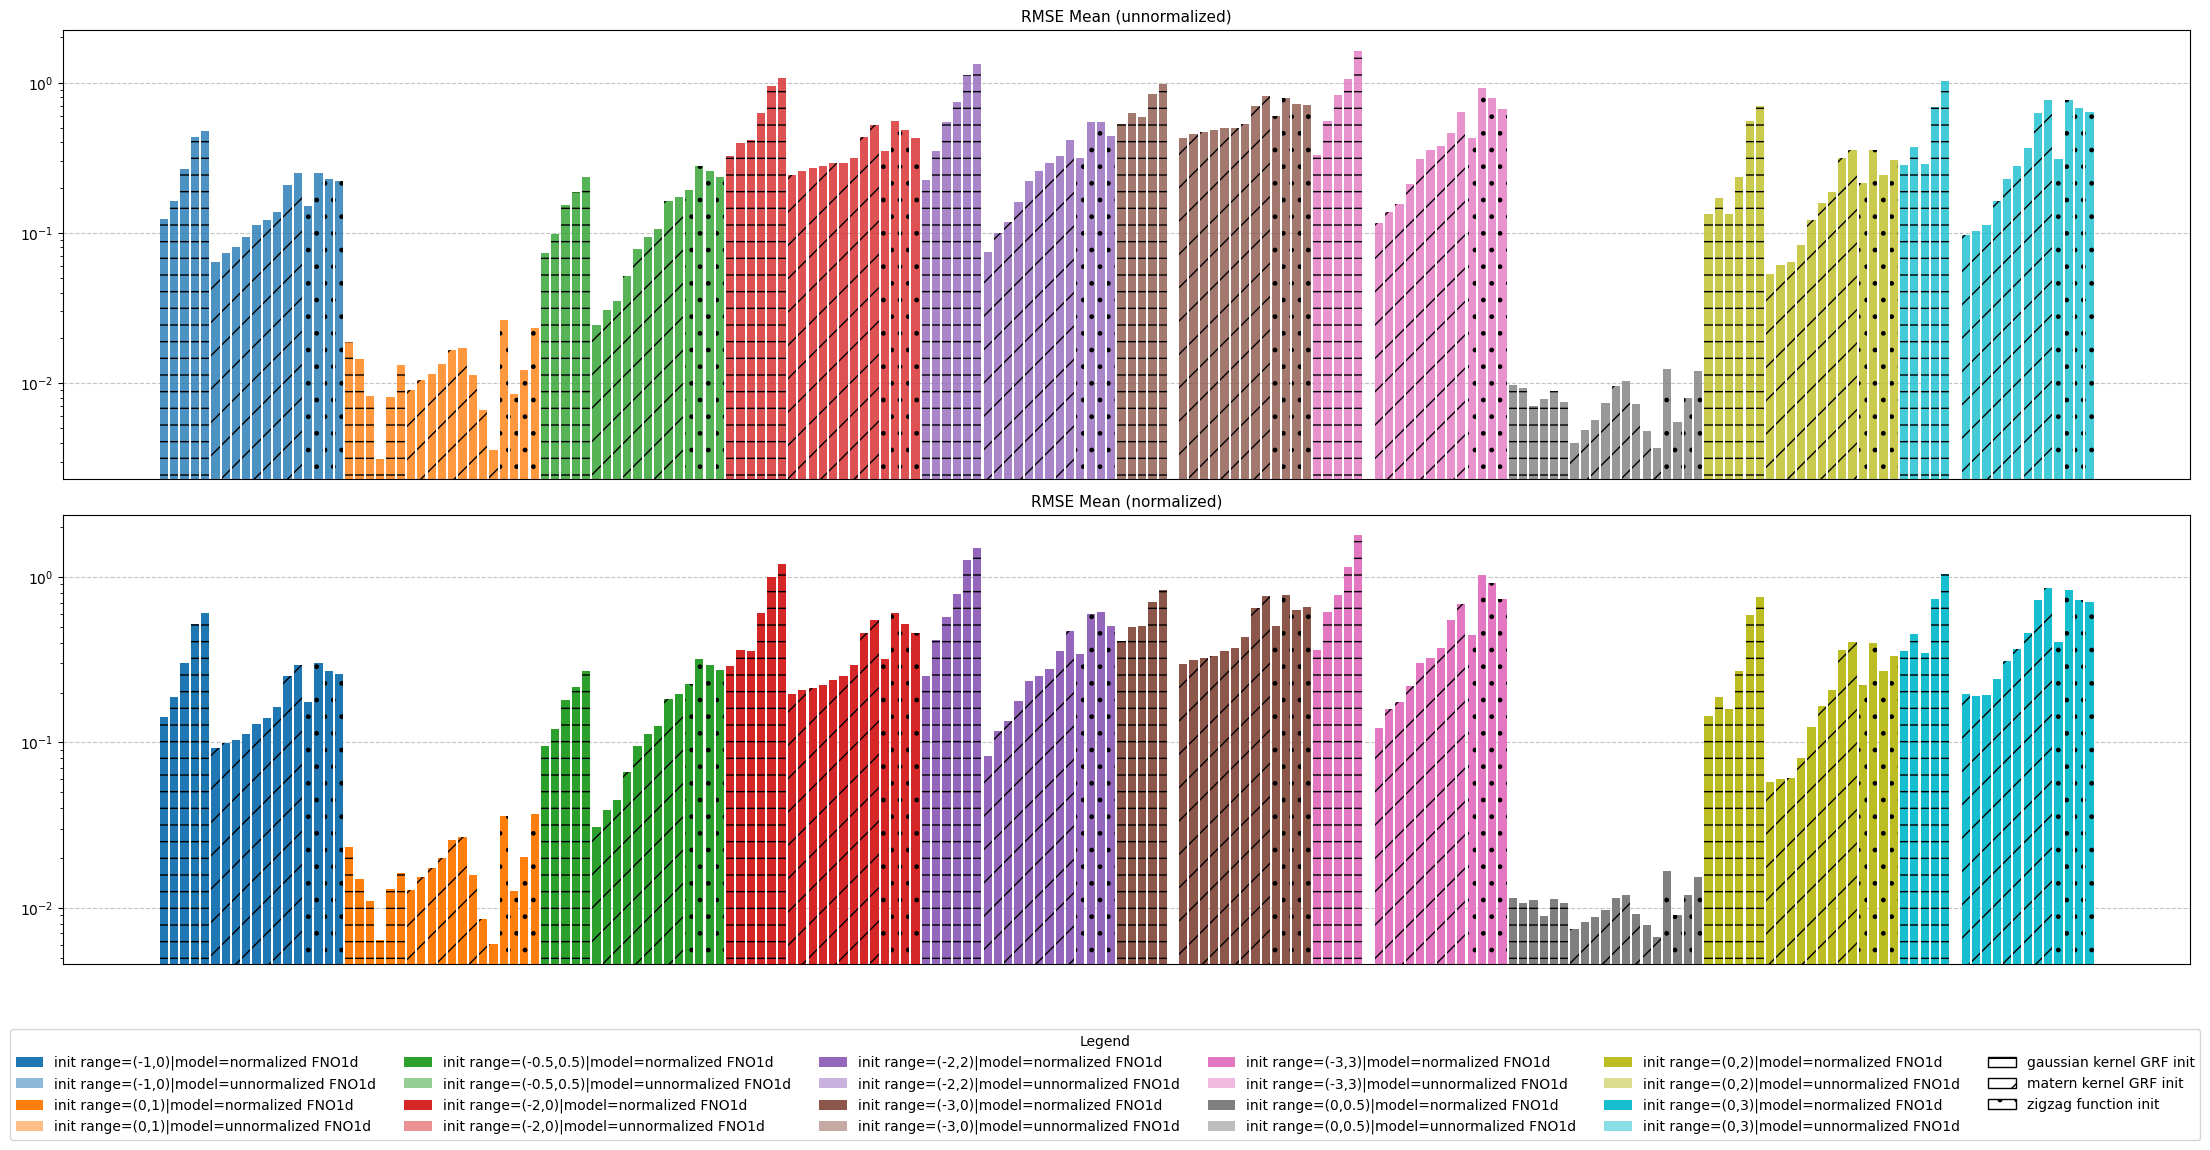

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re

# 假设 summary_df 已经存在

# 你的颜色和 alpha 映射逻辑不变
dataset_types = summary_df['dataset_type'].unique()
base_colors = dict(zip(dataset_types, plt.cm.tab10.colors[:len(dataset_types)]))

def get_color(row):
    base = base_colors[row['dataset_type']]
    alpha = 1.0 if row['normalization'] == 'norm' else 0.8
    return (*base[:10], alpha)

colors = summary_df.apply(get_color, axis=1)

# 提取 pattern
def extract_pattern(name):
    name = name.lower()
    if 'matern' in name:
        return 'matern'
    elif 'gaussian' in name:
        return 'gaussian'
    elif 'zigzag' in name:
        return 'zigzag'
    else:
        return 'other'

summary_df['pattern'] = summary_df['dataset_name'].apply(extract_pattern)

hatch_map = {
    'matern': '/',
    'gaussian': '-',
    'zigzag': '.',
    'other': None
}
hatches = summary_df['pattern'].map(hatch_map)

# 这里是完整label，确保唯一定位（避免重合）
summary_df['label'] = (
    summary_df['dataset_type'] + "_" +
    summary_df['normalization'] + "_" +
    summary_df['dataset_name']
)

# 生成简短label_2，画图时显示用
def make_label_2(row):
    name = row['dataset_name'].lower()
    pattern = row['pattern']
    if pattern == 'matern':
        cl = re.search(r'cl([0-9\.]+)', name)
        nu = re.search(r'nu([0-9\.]+)', name)
        cl_str = cl.group(1) if cl else '?'
        nu_str = nu.group(1) if nu else '?'
        return f"cl{cl_str}_nu{nu_str}"
    elif pattern == 'gaussian':
        cl = re.search(r'cl([0-9\.]+)', name)
        cl_str = cl.group(1) if cl else '?'
        return f"cl{cl_str}"
    elif pattern == 'zigzag':
        peaks = re.search(r'peaks([0-9]+)', name)
        peaks_str = peaks.group(1) if peaks else '?'
        return f"peaks{peaks_str}"
    else:
        return 'other'

# ——仅画 RMSE，按 normalization 分两行——
fig = plt.figure(figsize=(22, 12))

df_unnorm = summary_df[summary_df['normalization'] != 'norm']
df_norm   = summary_df[summary_df['normalization'] == 'norm']

# 取对应子集的颜色与hatch
colors_unnorm  = colors[df_unnorm.index]
colors_norm    = colors[df_norm.index]
hatches_unnorm = hatches[df_unnorm.index]
hatches_norm   = hatches[df_norm.index]

# === Row 1: UNNORMALIZED ===
ax1 = plt.subplot(2, 1, 1)
bars = ax1.bar(df_unnorm['label'], df_unnorm['rmse_mean'], color=colors_unnorm)
for bar, hatch in zip(bars, hatches_unnorm):
    if pd.notna(hatch) and hatch:
        bar.set_hatch(hatch)

ax1.set_yscale('log')
# 让网格线在图形元素后面
ax1.set_axisbelow(True)

# 只开 y 轴的主网格线，并设透明度
ax1.grid(axis='y', which='major', linestyle='--', linewidth=0.8, alpha=0.75)

ax1.set_title('RMSE Mean (unnormalized)', fontsize=11)
# 隐藏全部 x 轴元素
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax1.set_xlabel(None)
# 若要连底部轴线都去掉可使用：ax1.spines['bottom'].set_visible(False)

# === Row 2: NORMALIZED ===
ax2 = plt.subplot(2, 1, 2)
bars = ax2.bar(df_norm['label'], df_norm['rmse_mean'], color=colors_norm)
for bar, hatch in zip(bars, hatches_norm):
    if pd.notna(hatch) and hatch:
        bar.set_hatch(hatch)

ax2.set_yscale('log')
# 让网格线在图形元素后面
ax2.set_axisbelow(True)

# 只开 y 轴的主网格线，并设透明度
ax2.grid(axis='y', which='major', linestyle='--', linewidth=0.8, alpha=0.75)

ax2.set_title('RMSE Mean (normalized)', fontsize=11)
ax2.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax2.set_xlabel(None)
# ax2.spines['bottom'].set_visible(False)  # 可选

# ——底部图例（你现有的 legend_elements 代码保持不变）——
plt.tight_layout(rect=[0, 0.18, 1, 1])     # 预留更多底部空间给 legend
ncol = min(6, len(legend_elements))
fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, 0.04), ncol=ncol,
           title='Legend', frameon=True)

plt.show()


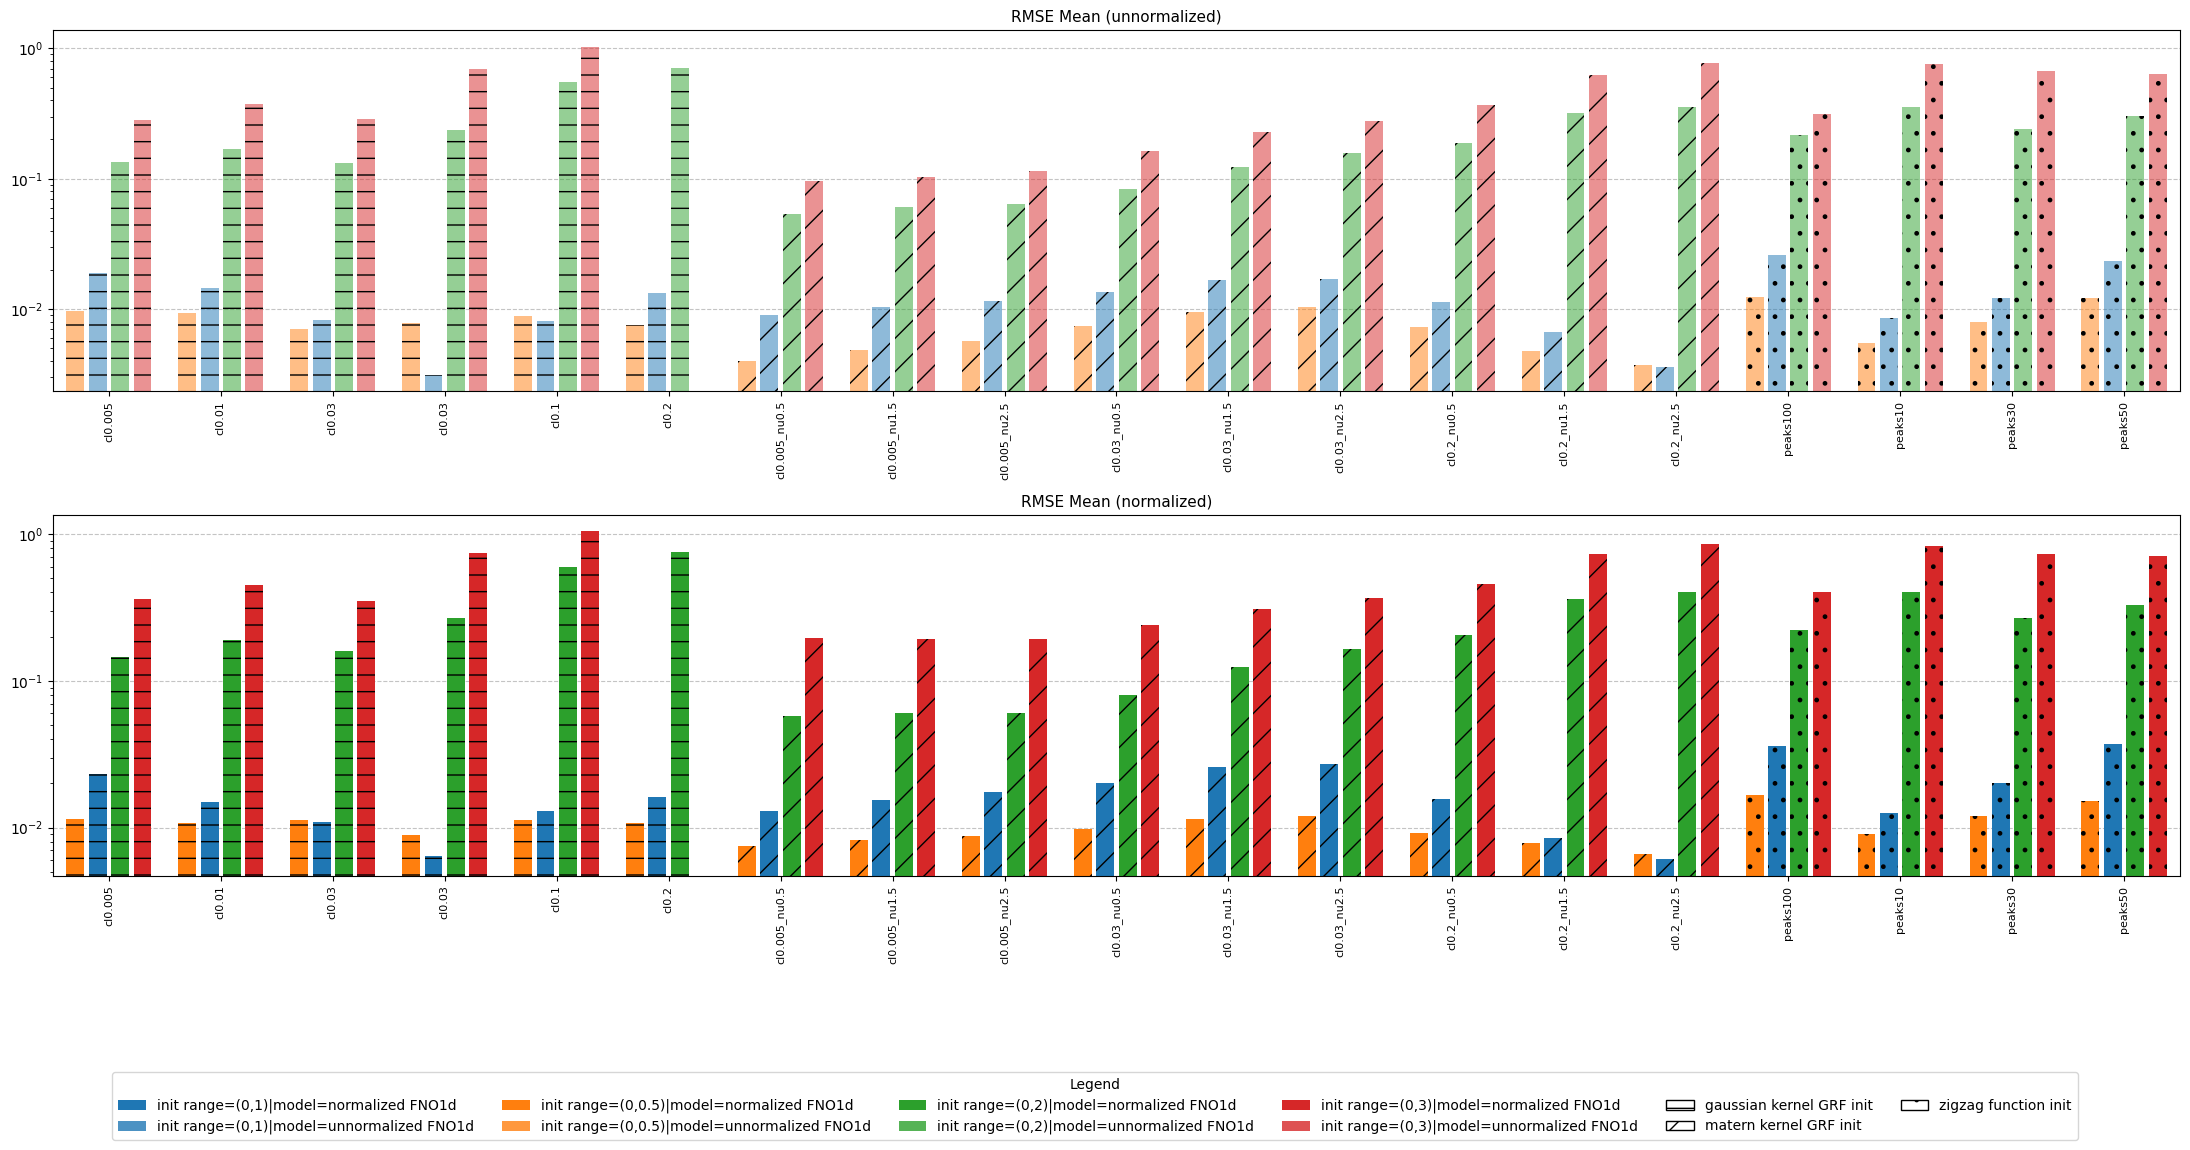

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re

# 你的颜色和 alpha 映射逻辑不变
dataset_types = summary_df['dataset_type'].unique()
base_colors = dict(zip(dataset_types, plt.cm.tab10.colors[:len(dataset_types)]))

def get_color(row):
    base = base_colors[row['dataset_type']]
    alpha = 1.0 if row['normalization'] == 'norm' else 0.5
    return (*base[:10], alpha)

colors = summary_df.apply(get_color, axis=1)

# 提取 pattern
def extract_pattern(name):
    name = name.lower()
    if 'matern' in name:
        return 'matern'
    elif 'gaussian' in name:
        return 'gaussian'
    elif 'zigzag' in name:
        return 'zigzag'
    else:
        return 'other'

summary_df['pattern'] = summary_df['dataset_name'].apply(extract_pattern)

hatch_map = {
    'matern': '/',
    'gaussian': '-',
    'zigzag': '.',
    'other': None
}
hatches = summary_df['pattern'].map(hatch_map)

# 这里是完整label，确保唯一定位（避免重合）
summary_df['label'] = (
    summary_df['dataset_type'] + "_" +
    summary_df['normalization'] + "_" +
    summary_df['dataset_name']
)

def make_label_2(row):
    name = row['dataset_name'].lower()
    pattern = row['pattern']
    if pattern == 'matern':
        cl = re.search(r'cl([0-9\.]+)', name)
        nu = re.search(r'nu([0-9\.]+)', name)
        cl_str = cl.group(1) if cl else '?'
        nu_str = nu.group(1) if nu else '?'
        return f"cl{cl_str}_nu{nu_str}"
    elif pattern == 'gaussian':
        cl = re.search(r'cl([0-9\.]+)', name)
        cl_str = cl.group(1) if cl else '?'
        return f"cl{cl_str}"
    elif pattern == 'zigzag':
        peaks = re.search(r'peaks([0-9]+)', name)
        peaks_str = peaks.group(1) if peaks else '?'
        return f"peaks{peaks_str}"
    else:
        return 'other'
    
# 先生成 label_2（组标签用它；它不含 range）
summary_df['label_2'] = summary_df.apply(make_label_2, axis=1)

# 解析 dataset_type -> 数值区间，用于“组内按 range 排序”
def parse_range(dtype: str):
    if isinstance(dtype, str) and dtype.startswith("range_"):
        m = re.match(r"range_(-?\d+\.?\d*)_(-?\d+\.?\d*)", dtype)
        if m:
            lo, hi = float(m.group(1)), float(m.group(2))
            return (lo, hi)
    # 三个特殊类别的等效区间
    if dtype == "all_pos":
        return (0.0, 1.0)
    if dtype == "all_neg":
        return (-1.0, 0.0)
    if dtype == "pos_neg":
        return (-0.5, 0.5)
    # 兜底：排到最后
    return (float("inf"), float("inf"))

# 全局的 range 顺序（按区间从小到大排序）
all_ranges = sorted(summary_df['dataset_type'].unique(), key=parse_range)

# 每组固定容纳多少个“range 槽位”
N_PER_GROUP = 4  # 你说“每10个bar一组”
# 如果你的实际 range 数不是 10，也没关系，这里会在一组里固定留 10 个位置
# 并只绘制实际存在的数据；多出来的位置就是空隙

# 组间空隙（以“一个柱宽”为单位）
GROUP_GAP = 1.0

# 把一个子集画成分组柱形图（只画 RMSE）
def draw_panel(ax, df_sub, title: str):
    # ——按“除 range 外的共同信息”分组：这里选 dataset_name（或你也可以改成 label_2 更直观）
    groups = []
    for gkey, gdf in df_sub.groupby('dataset_name', sort=False):
        # 该组内的有效 range（与全局顺序取交集，保持顺序）
        ranges_present = [r for r in all_ranges if r in set(gdf['dataset_type'].values)]
        groups.append((gkey, gdf, ranges_present))

    # 计算每组的 x 起点、中心位置、组标签
    x_positions, heights, color_list, hatch_list = [], [], [], []
    group_centers, group_labels = [], []

    for gi, (gkey, gdf, ranges_present) in enumerate(groups):
        base = gi * (N_PER_GROUP + GROUP_GAP)  # 组起点
        # 组标签：用 label_2（不含 range），任取该组一行来取 label_2
        label_2_val = gdf.iloc[0]['label_2']
        group_labels.append(label_2_val)
        group_centers.append(base + (N_PER_GROUP - 1) / 2.0)

        # 组内按全局 all_ranges 遍历，前 N_PER_GROUP 个位置作为槽位
        # 在槽位内只画实际存在的 range；不存在的就空着
        # 为了“每组看起来就是 10 个柱位”，我们把槽位限制在前 N_PER_GROUP 个 all_ranges
        for j, r in enumerate(all_ranges[:N_PER_GROUP]):
            # 该 range 在该组是否有数据
            row = gdf[gdf['dataset_type'] == r]
            if not row.empty:
                idx = row.index[0]
                x_positions.append(base + j)
                heights.append(row.iloc[0]['rmse_mean'])
                color_list.append(colors.loc[idx])
                hatch_list.append(hatches.loc[idx])
            # 如果不存在，就不追加任何东西，相当于留空位

    # 开始画图
    bars = ax.bar(x_positions, heights, color=color_list)
    for bar, h in zip(bars, hatch_list):
        if pd.notna(h) and h:
            bar.set_hatch(h)

    ax.set_yscale('log')
    ax.set_axisbelow(True)
    ax.grid(axis='y', which='major', linestyle='--', linewidth=0.8, alpha=0.75)
    ax.set_title(title, fontsize=11)

    # x 轴：只标“组”的标签（一个组一个）
    ax.set_xticks(group_centers)
    ax.set_xticklabels(group_labels, rotation=90, fontsize=8)
    # 显示底部刻度（只在组中心显示）
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

    # 可选：美化 x 轴范围，略微扩张到最后一组之后
    if group_centers:
        xmax = (len(groups) - 1) * (N_PER_GROUP + GROUP_GAP) + (N_PER_GROUP - 1)
        ax.set_xlim(-1, xmax + 1)

# ——仅画 RMSE，按 normalization 分两行——
fig = plt.figure(figsize=(22, 12))

df_unnorm = summary_df[summary_df['normalization'] != 'norm'].copy()
df_norm   = summary_df[summary_df['normalization'] == 'norm'].copy()

ax1 = plt.subplot(2, 1, 1)
draw_panel(ax1, df_unnorm, 'RMSE Mean (unnormalized)')

ax2 = plt.subplot(2, 1, 2)
draw_panel(ax2, df_norm, 'RMSE Mean (normalized)')

# ——底部图例（保持你原来的逻辑；下面给出一份可直接用的版本）——
label_map = {
    'all_pos': 'range=(0,1)',
    'all_neg': 'range=(-1,0)',
    'pos_neg': 'range=(-0.5,0.5)',
    "range_-2_0": "range=(-2,0)",
    "range_-2_2": "range=(-2,2)",
    "range_-3_0": "range=(-3,0)",
    "range_-3_3": "range=(-3,3)",
    "range_0_0.5": "range=(0,0.5)",
    "range_0_2": "range=(0,2)",
    "range_0_3": "range=(0,3)",
}
legend_elements = []
for dtype in dataset_types:
    display_label = label_map.get(dtype, dtype)
    legend_elements.append(Patch(facecolor=base_colors[dtype],
                                 label=f'init {display_label}|model=normalized FNO1d', alpha=1.0))
    legend_elements.append(Patch(facecolor=base_colors[dtype],
                                 label=f'init {display_label}|model=unnormalized FNO1d', alpha=0.8))

for hatch, label in {
    'gaussian': ('-', 'gaussian kernel GRF init'),
    'matern': ('/', 'matern kernel GRF init'),
    'zigzag': ('.', 'zigzag function init')
}.values():
    legend_elements.append(Patch(facecolor='white', edgecolor='black', hatch=hatch, label=label))

plt.tight_layout(rect=[0, 0.18, 1, 1])
ncol = min(6, len(legend_elements))
fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, 0.04), ncol=ncol,
           title='Legend', frameon=True)

plt.show()
